# El vacío en el tiempo, 2012 a 2026

El notebook 01 mide el vacío con la matriz de 2018, la última publicada. Este
lo lleva hacia atrás y hacia adelante. Hacia atrás, con las matrices reales de
2012, 2014 y 2016, asignadas a la red con el mismo método. Hacia adelante,
sin extrapolar una recta: cada producto de la matriz de 2018 se escala con la
serie pública que lo mueve, granos con la cosecha, combustibles con las
ventas, cemento con los despachos, la industria con el índice del INDEC, y la
arena de fractura con el registro de fractura, que la matriz nunca vio. Así
entran la pandemia, la sequía de 2023 y los cinco millones de toneladas de
arena, que son lo que cambió de verdad en la ruta.

Todo lo de 2019 en adelante es un escenario construido, no una medición, y
así se muestra en cada figura.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
from IPython.display import Image, display, HTML

from vlab import DATA_PROC, FIGURES
from vlab.od import zones, all_products
from vlab.network import load_network
from vlab.assign import build_graph, zone_nodes, assign, validate, sum_matrices
from vlab.drivers import SERIES, driver_table, factors, sand_by_year
from vlab.projection import PRODUCT_DRIVER, scale_matrices, yearly, yearly_links, link_empties_by_year
from vlab.figures import national_series, route_series, series_figure, animated_map
pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 60)
z = zones(); codes = list(z.codigo); net = load_network()

## 1. Asignar la matriz a la red, y comprobar que sale igual

La asignación oficial existe solo para 2018. Para los demás años hace falta
una propia: la red simplificada está conectada de punta a punta, cada tramo
tiene su largo y su velocidad de pesados, y cada par de zonas viaja por el
camino más rápido. Antes de usarla, se compara con la oficial del mismo año.

In [2]:
G, links = build_graph(net); nodos = zone_nodes(G, z)
Mc = all_products(2018, codes, unidad="camiones")
propia = assign(G, links, nodos, sum_matrices(Mc))
v = validate(propia, net)
print(f"grafo: {G.number_of_nodes()} nodos, {G.number_of_edges()} aristas; {len(Mc)} matrices de camiones, {sum_matrices(Mc).values.sum() / 1e6:,.1f} millones de camiones por año")
pd.Series(v)

grafo: 1413 nodos, 1729 aristas; 111 matrices de camiones, 23.1 millones de camiones por año


r_total                     8.620000e-01
r_sentido_mismo             8.450000e-01
r_sentido_cruzado           4.540000e-01
camiones_km_oficial         8.109904e+09
camiones_km_propio          8.538442e+09
cociente_km                 1.053000e+00
tramos_con_flujo_oficial    1.118000e+03
tramos_con_flujo_propio     1.030000e+03
pct_tramos_dentro_de_x2     8.120000e+01
dtype: float64

Correlación de 0,86 tramo por tramo, un 5 % más de camiones-kilómetro que la
oficial, y el sentido bien puesto: la correlación con los sentidos cruzados
cae a la mitad. Ocho de cada diez tramos quedan dentro de un factor dos. Es
el mismo método que usó la Secretaría, con menos detalle en los accesos
urbanos.

## 2. Los drivers: qué se movió después de 2018

Siete series de la API de datos.gob.ar, la producción por cultivo del
Ministerio de Agricultura y la arena del registro de fractura. La pandemia y
las sequías están ahí: el gasoil cae 11,6 % en 2020, la soja cae a la mitad
en 2023, y la arena pasa de 1,1 a 5,1 millones de toneladas entre 2018 y 2025.

In [3]:
print("series de la API:"); [print(f"  {k:11s} {v['que']}") for k, v in SERIES.items()]
d = driver_table(); arena = sand_by_year()
d.loc[2016:2026, ["gasoil", "cemento", "ipi", "isac", "soja", "maiz", "trigo", "arena_t"]].round(0)

series de la API:
  gasoil      ventas de gasoil, miles de m³ (Secretaría de Energía)
  nafta       ventas de nafta súper, miles de m³
  cemento     despachos de cemento portland, miles de t (AFCP)
  ipi         índice de producción industrial manufacturero, INDEC (desde 2016)
  isac        indicador sintético de la actividad de la construcción, INDEC
  siderurgia  IPI industria siderúrgica, INDEC (desde 2016)
  automotriz  producción automotriz, unidades (ADEFA)


,gasoil,cemento,ipi,isac,soja,maiz,trigo,arena_t
anio,,,,,,,,
2016,13675.0,200891.0,129.0,169.0,59095247.0,39792854.0,11314952.0,441233.0
2017,13718.0,217394.0,132.0,192.0,54972546.0,49490326.0,18395106.0,718290.0
2018,13491.0,198817.0,126.0,193.0,37785927.0,43462323.0,18518045.0,1110183.0
2019,13396.0,183883.0,118.0,178.0,55263891.0,56860704.0,19459727.0,1518028.0
2020,11928.0,180563.0,109.0,143.0,48780412.0,58395811.0,19776942.0,742487.0
2021,13715.0,195335.0,126.0,188.0,46217911.0,60525805.0,17644277.0,2292238.0
2022,14779.0,188178.0,132.0,194.0,43861066.0,59037179.0,22150287.0,3012721.0
2023,14668.0,190227.0,129.0,188.0,25044982.0,41409448.0,12555860.0,3176587.0
2024,13992.0,187906.0,117.0,136.0,48213216.0,57494500.0,15853154.0,3667353.0


In [4]:
f = factors(d, 2025)
m2025, tabla = scale_matrices(all_products(2018, codes), f)
print(f"{(tabla.driver == 'sin driver, plano').sum()} de {len(tabla)} productos quedan planos por falta de driver")
tabla.sort_values("factor", ascending=False).head(12)

61 de 111 productos quedan planos por falta de driver


,grupo,producto,driver,factor
52,"mineria extraccion de arenas, canto. rod. y trit. petreos",arena silicea,arena_t,4.554
23,granos,sorgo,sorgo,1.825
20,granos,girasol,girasol,1.581
22,granos,soja,soja,1.353
28,industrializados,aceites,soja,1.353
31,industrializados,fertilizantes,soja,1.353
25,granos,varios 1,soja,1.353
83,regionales,algodon,algodon,1.352
19,granos,cebada,cebada,1.289
21,granos,maiz,maiz,1.189


## 3. El vacío año por año

Con las matrices reales de 2012 a 2018 y los escenarios de 2019 a 2026, todo
asignado a la misma red. Lo que se mide es la diferencia entre la ida y la
vuelta de cada tramo, en camiones-kilómetro.

In [5]:
anios = tuple(a for a in range(2018, 2027) if a in d.index)
por_anio = yearly_links(Mc, d, arena, anios, G, links, nodos, codes)
proy = link_empties_by_year(por_anio, net)
hist = pd.read_csv(DATA_PROC / "tramos_vacio_historico.csv")
todo = pd.concat([hist, proy], ignore_index=True); todo.to_csv(DATA_PROC / "tramos_vacio_2012_2026.csv", index=False)
national_series(todo).round(2)

,camiones_km,vacios_km,arena_km,pct_vacio,medido
anio,,,,,
2012,9.70,4.15,0.00,42.75,True
2014,12.40,5.45,0.00,43.94,True
2016,9.59,4.30,0.00,44.78,True
2018,8.58,3.82,0.05,44.52,True
2019,9.05,4.04,0.06,44.64,False
2020,8.50,3.86,0.03,45.43,False
2021,9.05,4.03,0.10,44.50,False
2022,9.31,4.09,0.13,43.94,False
2023,8.50,3.67,0.13,43.16,False


Dos lecturas. La fracción vacía de la red es estable, entre 43 y 45 %, en
quince años: el vacío no depende del ciclo, depende de la geografía de la
producción. Y lo que sí cambia es el volumen: 2014 fue el pico de camiones
en la ruta, 2020 y 2023 los pozos, y la arena pasa de 50 a 210 millones de
camiones-kilómetro por año, casi todos en un solo corredor.

## 4. Las rutas de la arena

El control de todo el modelo: sin que nadie se lo diga, la asignación manda la
arena de Entre Ríos a Neuquén por la RN 152. Los camiones cargados por día
que salen de ahí se pueden comparar con los que midió arena-lab y con los que
cuenta La Pampa.

In [6]:
r152 = proy[proy.etiqueta == "RN 152"].groupby("anio").apply(lambda g: g[["ab_arena", "ba_arena"]].max(axis=1).sum() / g.id.count() / 300).rename("arena, camiones cargados por día")
print(r152.round(0).to_string())
route_series(todo, ("RN 152", "RN 5", "RN 151", "RN 35", "RN 22", "RN 12")).round(0)

anio
2018    120.0
2019    165.0
2020     79.0
2021    251.0
2022    331.0
2023    349.0
2024    404.0
2025    558.0
2026    479.0


etiqueta,RN 12,RN 151,RN 152,RN 22,RN 35,RN 5
anio,,,,,,
2012,42.0,75.0,37.0,30.0,37.0,13.0
2014,39.0,48.0,39.0,28.0,15.0,36.0
2016,41.0,67.0,15.0,54.0,42.0,21.0
2018,49.0,40.0,60.0,47.0,57.0,14.0
2019,48.0,36.0,62.0,46.0,56.0,16.0
2020,48.0,38.0,57.0,47.0,57.0,11.0
2021,49.0,33.0,65.0,43.0,53.0,23.0
2022,49.0,29.0,68.0,42.0,51.0,28.0
2023,51.0,28.0,68.0,42.0,49.0,33.0


En 2025 la asignación da 558 camiones cargados de arena por día en la RN 152;
arena-lab, con otro método, 561; La Pampa cuenta 1.200 pasadas contando la
vuelta. Y el efecto sobre el vacío no es el mismo en todas las rutas: la RN 152
sube de 60 a 73 % y la RN 5 de 14 a 40 %, porque la arena va en el sentido
que ya estaba cargado. Pero la RN 151 baja de 40 a 15 % y la RN 35 de 57 a
42 %: ahí la arena viaja en el sentido que antes volvía vacío y lo llena. Un
mismo flujo agranda el vacío en una ruta y lo achica en la siguiente.

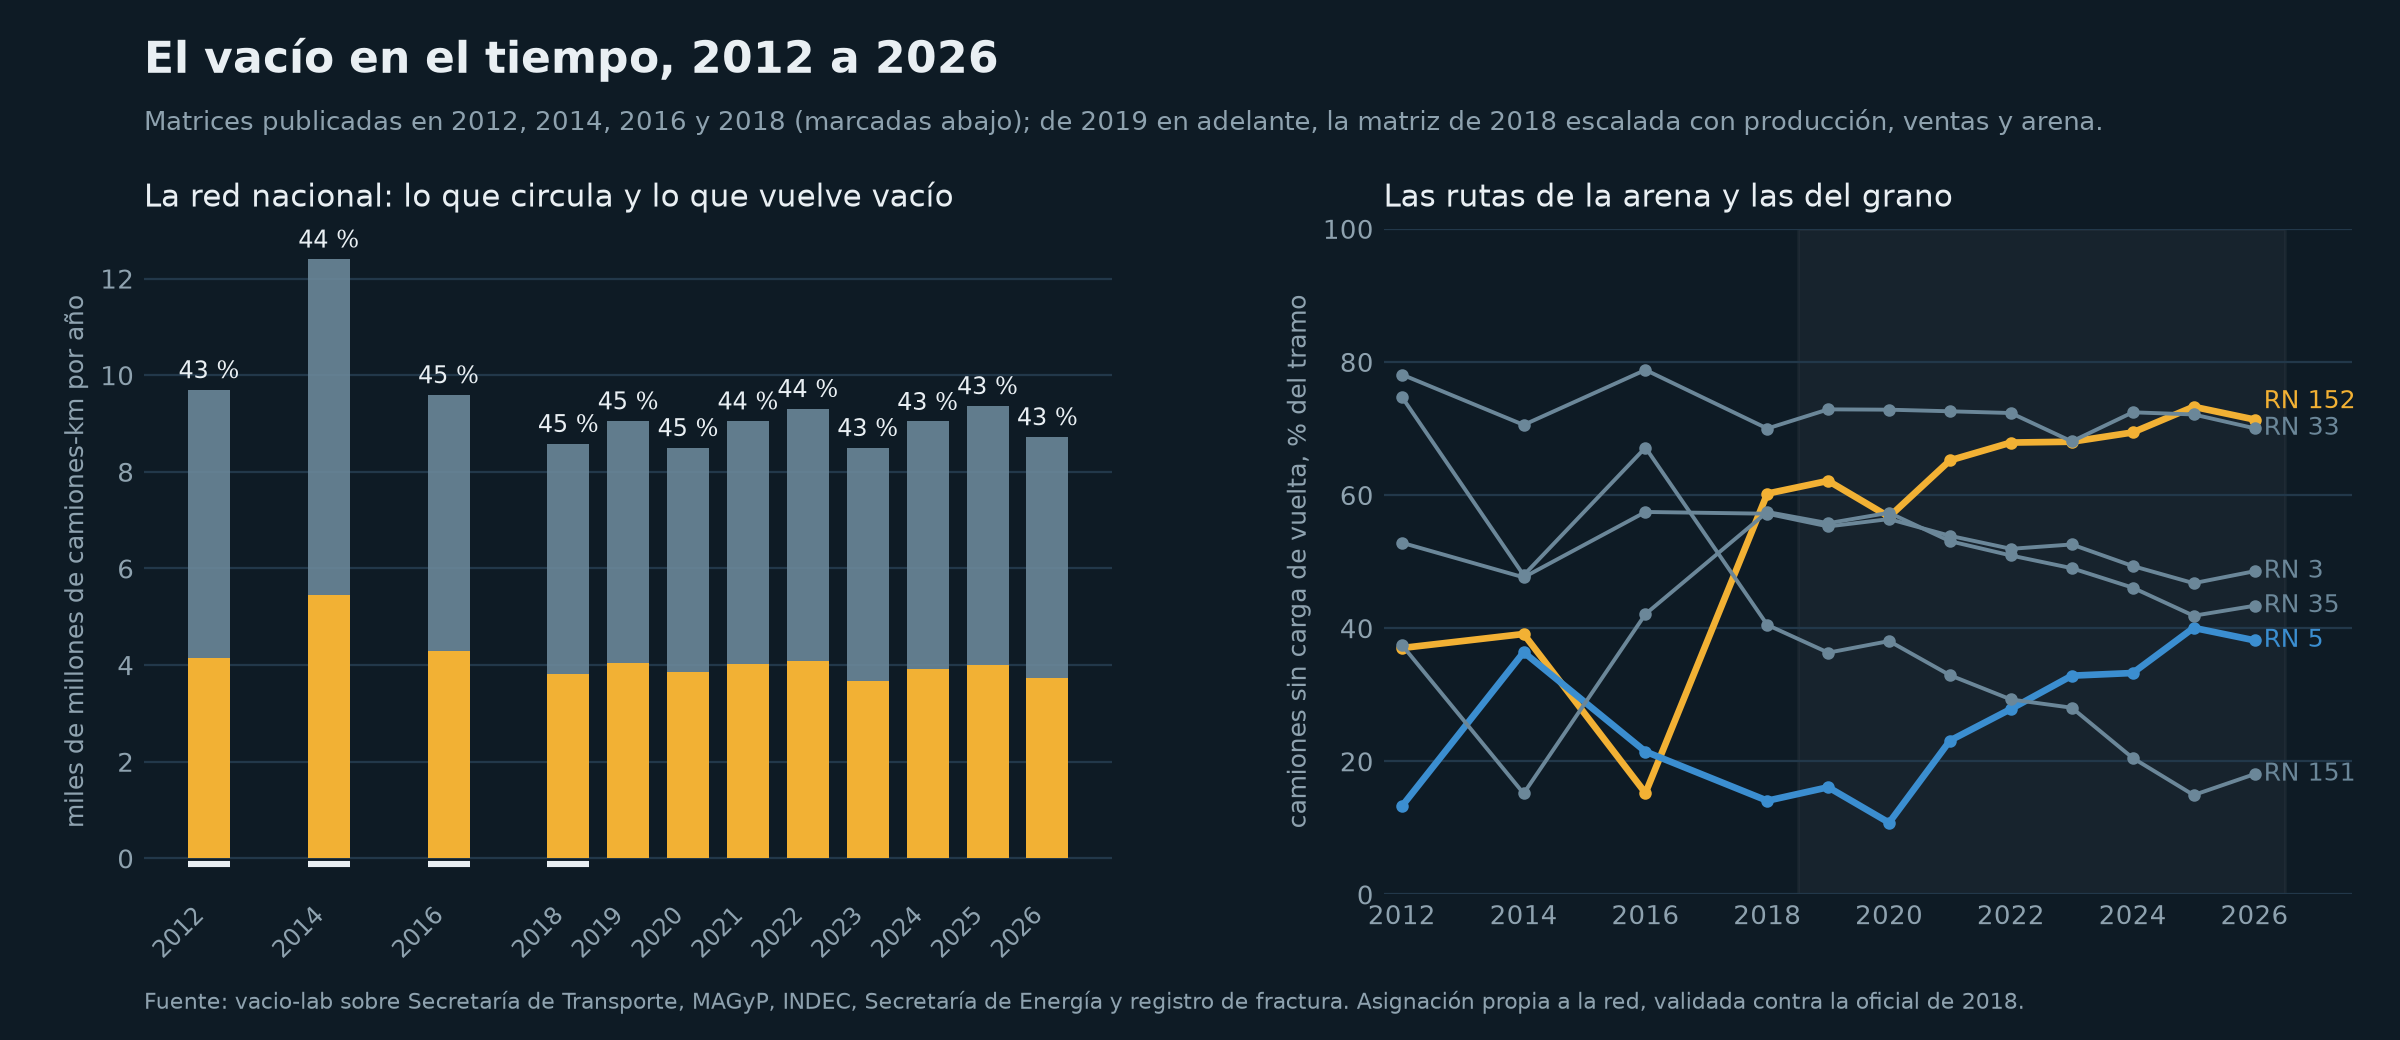

In [7]:
fig = series_figure(todo, FIGURES / "vacio_en_el_tiempo.png")
display(Image(filename=str(fig)))

## 5. Dónde apareció vacío nuevo

Los tramos donde más creció el vacío entre 2018 y 2025, en camiones por día,
y cuánto de su tránsito de 2025 es arena.

In [8]:
a, b = proy[proy.anio == 2018].set_index("id"), proy[proy.anio == 2025].set_index("id")
c = a[["etiqueta", "provincia", "km", "pct_vacio", "vacio_dia"]].join(b[["pct_vacio", "vacio_dia", "total_arena", "total"]].rename(columns={"pct_vacio": "pct_2025", "vacio_dia": "vacio_dia_2025", "total": "total_2025"}))
c["vacio_nuevo_dia"] = c.vacio_dia_2025 - c.vacio_dia; c["arena_pct"] = 100 * c.total_arena / c.total_2025
c.sort_values("vacio_nuevo_dia", ascending=False).head(12)[["etiqueta", "provincia", "km", "pct_vacio", "pct_2025", "vacio_nuevo_dia", "arena_pct"]].round(0)

,etiqueta,provincia,km,pct_vacio,pct_2025,vacio_nuevo_dia,arena_pct
id,,,,,,,
407,RN 33,SANTA FE,5.0,82.0,82.0,1821.0,0.0
925,RN A008,SANTA FE,3.0,57.0,60.0,1268.0,0.0
102,RN 14,ENTRE RIOS,9.0,59.0,66.0,965.0,12.0
104,RN 14,ENTRE RIOS,56.0,61.0,67.0,917.0,12.0
55,RN 12,ENTRE RIOS,80.0,55.0,62.0,901.0,11.0
801,RN A00,SANTA FE,2.0,49.0,53.0,754.0,0.0
802,RN A00,SANTA FE,4.0,49.0,53.0,754.0,0.0
719,RN 9,BUENOS AIRES,10.0,48.0,51.0,708.0,5.0
415,RN 34,SANTA FE,174.0,48.0,53.0,559.0,0.0


El vacío nuevo más grande no es el de la arena: son los accesos a Rosario y
las rutas de Entre Ríos, RN 33, RN 14 y RN 12, empujados por una cosecha de
soja un 35 % mayor que la de 2018. La arena aparece en los mismos tramos de
Entre Ríos con un 11 a 12 % del tránsito. El grano sigue siendo el vacío del
país; la arena es el vacío de un corredor.

In [9]:
gif = animated_map(todo, net, FIGURES / "mapa_vacio_2012_2026.gif")
display(HTML(f'<img src="../docs/figures/mapa_vacio_2012_2026.gif" width="520">'))

## Límites

- De 2019 en adelante es un escenario: la matriz de 2018 con otros volúmenes.
  La estructura de orígenes y destinos no cambia, y en la realidad cambió,
  por ejemplo con las nuevas plantas de arena en Entre Ríos.
- 50 de los 111 productos tienen driver; los demás quedan planos. Los grandes
  lo tienen: granos, combustibles, cemento, arena.
- La asignación propia difiere de la oficial en un 5 % de camiones-kilómetro
  y tiene menos detalle en accesos urbanos.
- Las matrices de 2012 a 2016 usan zonificaciones y métodos que cambiaron
  entre ediciones; el salto de 2014 puede ser de método, no de camiones.
- La arena entra como un solo par, Gualeguaychú a Neuquén, con 30 toneladas
  por viaje, en el registro de fractura de la cuenca Neuquina. Los años
  parciales se anualizan por los meses con volumen real.
- La matriz de 2022 del CESPA (UBA) sería el control natural de este
  escenario; no está publicada como archivo abierto.